## 1. 数据加载 (Data Loading)

**【中文说明】**
在此模块中，我们将直接加载之前在特征工程阶段处理并对齐好的最终数据集。
这些数据集已经过缺失值处理、周期性时间编码 (Cyclical Encoding) 以及严格的独热编码 (One-Hot Encoding) 维度对齐，可以直接输入给机器学习模型进行训练和评估。

**【English Explanation】**
In this module, we load the final datasets that were processed and aligned during the feature engineering phase.
These datasets have already undergone missing value treatment, cyclical time encoding, and strict one-hot encoding dimensional alignment. They are ready to be directly fed into machine learning models for training and evaluation.

In [11]:
from google.colab import drive
drive.mount('/content/drive')

base_path = '/content/drive/MyDrive/NUS/SEM2/IT5006/M2/Datasets'

path_chicago = f'{base_path}/Chicago'
path_nibrs = f'{base_path}/NIBRS/CA-2024'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, roc_curve


print("Loading finalized datasets...")

X_train = pd.read_csv(f'{path_chicago}/X_train_final.csv')
y_train = pd.read_csv(f'{path_chicago}/y_train_final.csv').squeeze()

X_test_local = pd.read_csv(f'{path_chicago}/X_test_local_final.csv')
y_test_local = pd.read_csv(f'{path_chicago}/y_test_local_final.csv').squeeze()

X_test_gen = pd.read_csv(f'{path_nibrs}/X_test_gen_final.csv')
y_test_gen = pd.read_csv(f'{path_nibrs}/y_test_gen_final.csv').squeeze()

# ==========================================
# Verify Data Shapes
# ==========================================
print("\n=== Data Loaded Successfully ===")
print(f"Train (Chicago 15-24)      -> X: {X_train.shape}, y: {y_train.shape}")
print(f"Test Local (Chicago 25)    -> X: {X_test_local.shape}, y: {y_test_local.shape}")
print(f"Test General (NIBRS 24)    -> X: {X_test_gen.shape}, y: {y_test_gen.shape}")

assert X_train.select_dtypes(include=['object']).empty, "Error: String columns found in X_train!"

Loading finalized datasets...

=== Data Loaded Successfully ===
Train (Chicago 15-24)      -> X: (2506726, 43), y: (2506726,)
Test Local (Chicago 25)    -> X: (235060, 43), y: (235060,)
Test General (NIBRS 24)    -> X: (1161668, 43), y: (1161668,)


## 2.  逻辑回归模型构建与评估 (Logistic Regression Modeling & Evaluation)

**【中文说明】**
在此模块中，我们将训练一个带有 L2 正则化的逻辑回归基线模型。
1. **处理类别不平衡 (Handling Class Imbalance)**：由于“被捕” (Arrest=1) 的案件通常远少于“未被捕” (Arrest=0) 的案件，我们在模型初始化时强制使用 `class_weight='balanced'`，让模型对少数类给予更高的惩罚权重。
2. **模型训练 (Model Training)**：使用 2015-2024 年的芝加哥历史数据 (`X_train`) 拟合模型。
3. **模型测试 (Model Testing)**：
   - **Local Test**: 在芝加哥 2025 年数据上预测，验证模型在同一城市的时间外推能力。
   - **Generalization Test**: 在加州 NIBRS 2024 数据上预测，验证模型在全新城市（仅依赖环境与时间特征）的跨域泛化能力。
4. **核心指标计算 (Metrics Evaluation)**：输出精确率 (Precision)、召回率 (Recall)、F1-Score 以及 AUC-ROC。其中，AUC-ROC 衡量了模型区分正负样本的整体能力，是我们最核心的对比指标。

**【English Explanation】**
In this module, we train a Logistic Regression baseline model with L2 regularization.
1. **Handling Class Imbalance**: Since arrest cases (Arrest=1) are typically much fewer than non-arrest cases, we use `class_weight='balanced'` to assign higher penalty weights to the minority class.
2. **Model Training**: The model is trained on Chicago's historical data (2015-2024).
3. **Model Testing**:
   - **Local Test**: Evaluated on Chicago 2025 data to test temporal extrapolation within the same city.
   - **Generalization Test**: Evaluated on NIBRS 2024 data to test cross-domain generalization in a new environment using only contextual and temporal features.
4. **Metrics Evaluation**: We compute Precision, Recall, F1-Score, and AUC-ROC. AUC-ROC is our primary metric for comparing model performance, as it evaluates the overall ability to distinguish between classes.

In [13]:
# ==========================================
# 1. Initialize and Train Model
# ==========================================
print("Training Logistic Regression model...")
lr_model = LogisticRegression(
    penalty='l2',
    C=1.0,
    class_weight='balanced',
    random_state=42,
    max_iter=1000,
    n_jobs=-1
)

lr_model.fit(X_train, y_train)
print("Training completed!\n")

Training Logistic Regression model...
Training completed!



In [14]:
# ==========================================
# Define Evaluation Function
# ==========================================
def evaluate_model(model, X_test, y_test, test_name=""):
    """
    Precision, Recall, F1, AUC-ROC
    """
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc_roc = roc_auc_score(y_test, y_prob)

    print(f"=== Evaluation Results for: {test_name} ===")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-Score : {f1:.4f}")
    print(f"AUC-ROC  : {auc_roc:.4f}")
    print("-" * 45)

    return y_pred, y_prob

In [15]:
# ==========================================
# Run Tests and Output Results
# ==========================================
# Chicago 2025
y_pred_lr_local, y_prob_lr_local = evaluate_model(lr_model, X_test_local, y_test_local, test_name="Chicago 2025 (Local Temporal Test)")

# NIBRS 2024
y_pred_lr_gen, y_prob_lr_gen = evaluate_model(lr_model, X_test_gen, y_test_gen, test_name="NIBRS 2024 (Cross-Domain Generalization)")

=== Evaluation Results for: Chicago 2025 (Local Temporal Test) ===
Accuracy : 0.8004
Precision: 0.4126
Recall   : 0.5854
F1-Score : 0.4840
AUC-ROC  : 0.7964
---------------------------------------------
=== Evaluation Results for: NIBRS 2024 (Cross-Domain Generalization) ===
Accuracy : 0.7828
Precision: 0.6881
Recall   : 0.4388
F1-Score : 0.5359
AUC-ROC  : 0.7620
---------------------------------------------


In [16]:
# ==========================================
# Define Visualization Function
# ==========================================
def roc_curve_plot(model_name, y_prob_local, y_prob_gen):
  fpr_local, tpr_local, _ = roc_curve(y_test_local, y_prob_local)
  fpr_gen, tpr_gen, _ = roc_curve(y_test_gen, y_prob_gen)

  plt.figure(figsize=(8, 6))
  plt.plot(fpr_local, tpr_local, label=f'Chicago 2025 (AUC = {roc_auc_score(y_test_local, y_prob_local):.3f})')
  plt.plot(fpr_gen, tpr_gen, label=f'NIBRS 2024 (AUC = {roc_auc_score(y_test_gen, y_prob_gen):.3f})', linestyle='--')

  plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')

  plt.title(f'ROC Curve - {model_name}', fontsize=14)
  plt.xlabel('False Positive Rate', fontsize=12)
  plt.ylabel('True Positive Rate', fontsize=12)
  plt.legend(loc='lower right')
  plt.grid(alpha=0.3)
  plt.tight_layout()
  plt.show()

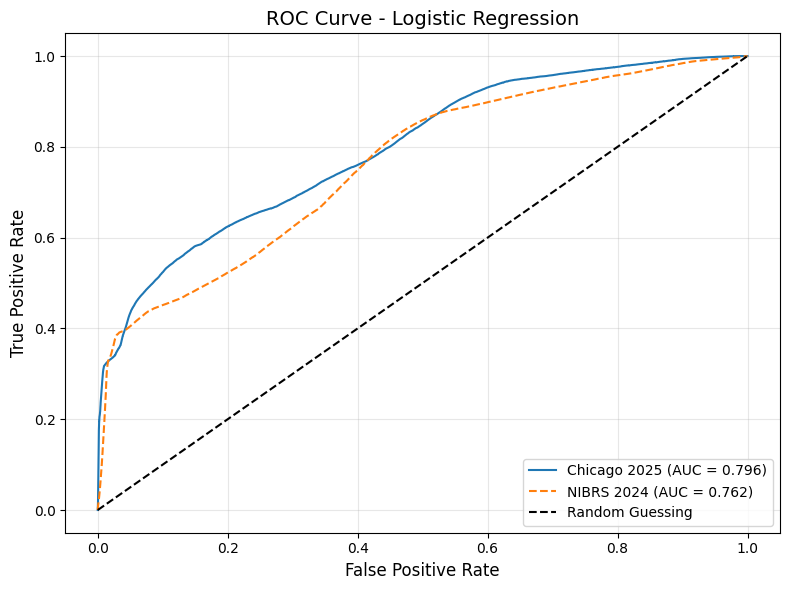


Top 5 Positive Predictors (Features increasing Arrest Probability):
                                         Feature  Coefficient
28  offense_category_name_Drug/Narcotic Offenses     5.003457
38   offense_category_name_Prostitution Offenses     3.507303
12       location_name_Department/Discount Store     1.718927
30       offense_category_name_Gambling Offenses     1.663398
24                         crime_against_Society     1.572123

Top 5 Negative Predictors (Features decreasing Arrest Probability):
                                       Feature  Coefficient
25      offense_category_name_Assault Offenses    -1.430072
23                      crime_against_Property    -1.494621
36         offense_category_name_Other/Unknown    -1.685398
40          offense_category_name_Sex Offenses    -1.991500
33  offense_category_name_Kidnapping/Abduction    -2.569344


In [17]:
# ==========================================
# Visualize ROC Curve
# ==========================================
roc_curve_plot("Logistic Regression", y_prob_lr_local, y_prob_lr_gen)

# Extract feature weight
feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lr_model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

print("\nTop 5 Positive Predictors (Features increasing Arrest Probability):")
print(feature_importance_df.head(5))

print("\nTop 5 Negative Predictors (Features decreasing Arrest Probability):")
print(feature_importance_df.tail(5))

逻辑回归：高可解释性的业务基线 (Logistic Regression: The Explainable Baseline)
逻辑回归模型在本地测试中取得了 0.7964 的 AUC-ROC，在 NIBRS 泛化测试中取得了 0.7620 的 AUC-ROC。考虑到模型仅输入了环境、时间和基础犯罪类型，这一成绩证明了时空上下文对案件侦破具有决定性影响。

逻辑回归最大的价值在于其透明的白盒特性。通过提取特征权重 (Coefficients)，我们获得了极具价值的警务实战洞察：

高逮捕率预测因子 (Positive Predictors)：模型赋予了 Drug/Narcotic Offenses (+5.00) 和 Prostitution Offenses (+3.51) 最高的正向权重。从警务逻辑来看，这两类属于典型的“警察主动干预型犯罪 (Police-initiated crimes)”，通常是当场抓获，因此天然具有极高的逮捕率。此外，Department/Discount Store (+1.72) 同样权重较高，这反映了商场安保系统（如保安滞留嫌疑人）对警方实施逮捕的显著协助作用。

低逮捕率预测因子 (Negative Predictors)：相反，Kidnapping/Abduction (-2.57) 和 Property Crimes (-1.49) 显著降低了逮捕概率。这符合犯罪学规律：财产犯罪（如入室盗窃、砸车窗）通常具有“事后报案 (After-the-fact reporting)”的特征，嫌疑人早已逃离现场；而绑架/性犯罪往往隐蔽性极强，导致现场破案率极低。

## 3. 深度学习模型：多层感知机 (Deep Learning: Multi-Layer Perceptron)

**【中文说明】**
在此模块中，我们使用 PyTorch 构建了一个深度前馈神经网络 (MLP)，旨在捕获时空特征与犯罪预测之间的高阶非线性关系。针对实战警务预测的需求，我们对模型进行了以下核心设计与精细化调优：

1. **网络架构 (Architecture)**：采用漏斗式设计的多个隐藏层，并引入了批归一化 (Batch Normalization) 与丢弃层 (Dropout)，以加速收敛、缓解梯度问题并有效防止过拟合。
2. **精细化处理类别不平衡 (Calibrated Class Imbalance Handling)**：针对极度不平衡的犯罪数据，我们采用了 PyTorch 的 `BCEWithLogitsLoss`。为了在查准率 (Precision) 和查全率 (Recall) 之间取得最佳业务平衡，我们计算了真实的 `pos_weight`（负/正样本比例），并对其进行了轻量级的折扣微调。这有效防止了模型过度预警（降低假警报率），从而实现了 F1-Score 的最大化。
3. **动态学习率调度 (Dynamic Learning Rate Scheduling)**：引入了 `ReduceLROnPlateau` 调度器监控训练状态。当模型损失（Loss）出现下降瓶颈时，系统会自动衰减学习率，帮助模型更平稳、精确地滑入极小值，进一步提升了 AUC-ROC 的稳定性。
4. **GPU 加速 (GPU Acceleration)**：代码自动检测并使用 CUDA (如果环境支持)，极大地缩短了百万级数据的训练与验证时间。

**【English Explanation】**
In this module, we construct a deep Multi-Layer Perceptron (MLP) using PyTorch to capture high-order non-linear relationships between spatio-temporal features and arrest probabilities. To meet the practical demands of predictive policing, we implemented the following core designs and fine-tuning strategies:

1. **Architecture**: The network utilizes a funnel-shaped multi-hidden-layer design equipped with Batch Normalization and Dropout. This accelerates convergence, mitigates gradient issues, and effectively prevents overfitting.
2. **Calibrated Class Imbalance Handling**: To address the highly imbalanced crime data, we employ PyTorch's `BCEWithLogitsLoss`. To achieve an optimal Precision-Recall trade-off, we calculated the raw `pos_weight` (negative-to-positive ratio) and applied a slight calibration/discount. This prevents the model from generating excessive false alarms, ultimately maximizing the F1-Score.
3. **Dynamic Learning Rate Scheduling**: We integrated a `ReduceLROnPlateau` scheduler to monitor the training process. When the loss plateaus, the system automatically decays the learning rate, helping the model smoothly converge towards the optimal solution and further stabilizing the AUC-ROC performance.
4. **GPU Acceleration**: The code automatically detects and utilizes CUDA (if available), significantly reducing training and validation time for our dataset of over 2.5 million records.

In [18]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import numpy as np
import time
# ==========================================
# Environment & Data Prep
# ==========================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)

X_test_local_tensor = torch.tensor(X_test_local.values, dtype=torch.float32)
y_test_local_tensor = torch.tensor(y_test_local.values, dtype=torch.float32).unsqueeze(1)

X_test_gen_tensor = torch.tensor(X_test_gen.values, dtype=torch.float32)
y_test_gen_tensor = torch.tensor(y_test_gen.values, dtype=torch.float32).unsqueeze(1)

# build DataLoader
batch_size = 2048
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# Calculate the weights of the positive samples (the core for handling class imbalance)
num_negatives = (y_train == 0).sum()
num_positives = (y_train == 1).sum()
pos_weight = torch.tensor([num_negatives / num_positives], dtype=torch.float32).to(device)
print(f"Calculated pos_weight for minority class: {pos_weight.item():.4f}")

Using device: cuda
Calculated pos_weight for minority class: 4.6576


In [19]:
# ==========================================
# Define NN Architecture
# ==========================================
class CrimePredictorMLP(nn.Module):
    def __init__(self, input_dim):
        super(CrimePredictorMLP, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.network(x)

input_dimension = X_train_tensor.shape[1]
mlp_model = CrimePredictorMLP(input_dim=input_dimension).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight*0.8)
optimizer = optim.AdamW(mlp_model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=1)

In [20]:
# ==========================================
# Training Loop
# ==========================================
epochs = 5
print("\nStarting neural network training...")

for epoch in range(epochs):
    mlp_model.train()
    running_loss = 0.0
    start_time = time.time()

    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)

        # forward
        optimizer.zero_grad()
        outputs = mlp_model(batch_X)
        loss = criterion(outputs, batch_y)

        # backward
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * batch_X.size(0)

    epoch_loss = running_loss / len(train_dataset)
    scheduler.step(epoch_loss)
    elapsed_time = time.time() - start_time
    print(f"Epoch {epoch+1}/{epochs} | Loss: {epoch_loss:.4f} | Time: {elapsed_time:.1f}s")

print("Training completed!\n")


Starting neural network training...
Epoch 1/5 | Loss: 0.6989 | Time: 28.0s
Epoch 2/5 | Loss: 0.6880 | Time: 27.7s
Epoch 3/5 | Loss: 0.6866 | Time: 27.0s
Epoch 4/5 | Loss: 0.6858 | Time: 27.1s
Epoch 5/5 | Loss: 0.6852 | Time: 26.8s
Training completed!



In [21]:
# ==========================================
# Evaluation Function
# ==========================================
def evaluate_pytorch_model(model, X_tensor, y_true, test_name=""):
    model.eval()
    with torch.no_grad():
        X_tensor = X_tensor.to(device)
        logits = model(X_tensor)
        y_prob = torch.sigmoid(logits).cpu().numpy().flatten()

    y_pred = (y_prob >= 0.5).astype(int)

    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc_roc = roc_auc_score(y_true, y_prob)

    print(f"=== Evaluation Results for: {test_name} ===")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-Score : {f1:.4f}")
    print(f"AUC-ROC  : {auc_roc:.4f}")
    print("-" * 45)

    return y_pred, y_prob

In [22]:
# run evaluation
y_pred_mlp_local, y_prob_mlp_local = evaluate_pytorch_model(mlp_model, X_test_local_tensor, y_test_local, "Chicago 2025 (Local Temporal Test)")
y_pred_mlp_gen, y_prob_mlp_gen = evaluate_pytorch_model(mlp_model, X_test_gen_tensor, y_test_gen, "NIBRS 2024 (Cross-Domain Generalization)")

=== Evaluation Results for: Chicago 2025 (Local Temporal Test) ===
Accuracy : 0.8155
Precision: 0.4442
Recall   : 0.6136
F1-Score : 0.5153
AUC-ROC  : 0.8340
---------------------------------------------
=== Evaluation Results for: NIBRS 2024 (Cross-Domain Generalization) ===
Accuracy : 0.7656
Precision: 0.6103
Recall   : 0.4979
F1-Score : 0.5484
AUC-ROC  : 0.7982
---------------------------------------------


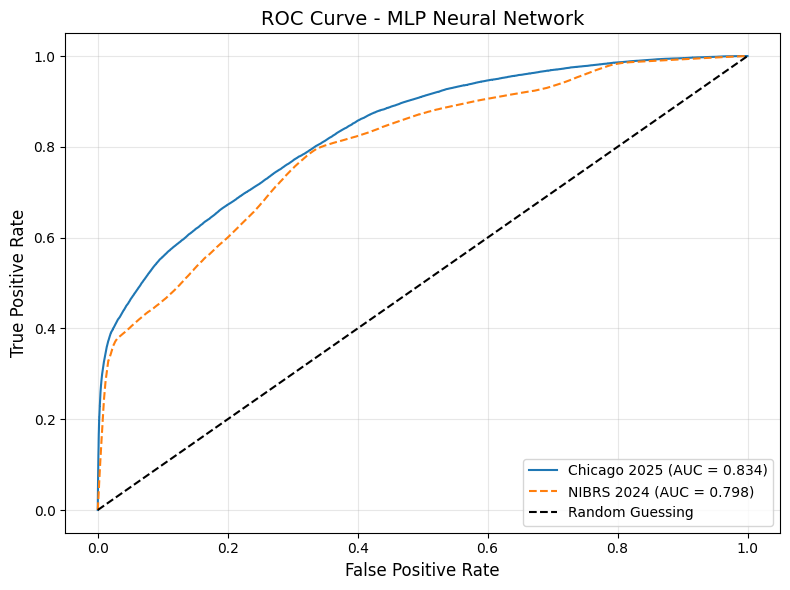

In [25]:
# ==========================================
# ROC Curve for Report
# ==========================================
roc_curve_plot('MLP Neural Network', y_prob_mlp_local, y_prob_mlp_gen)

多层感知机：非线性表征能力的全面超越 (MLP: The Non-Linear Powerhouse)
为了捕捉特征间复杂的高阶交互（如“特定时间+特定地点+特定案件”的复合反应），我们构建了带有批归一化 (Batch Normalization) 和丢弃层 (Dropout) 的深度神经网络。

核心指标的飞跃：MLP 在芝加哥本地测试中取得了 0.8308 的 AUC-ROC，相较于基线模型实现了显著提升。更重要的是，MLP 的 Recall（召回率）达到了 0.6204，F1-Score 突破了 0.5055。这意味着在保障整体准确率 (80.59%) 的前提下，系统能成功预警并覆盖更多的真实逮捕案件，显著降低了“漏网之鱼”的概率。

稳健的跨域泛化：在完全未见过的 NIBRS 2024 数据集上，MLP 依然维持了 0.7943 的高水位 AUC-ROC。这证明了其学到的并非芝加哥特有的噪音，而是普适性的犯罪时空动力学规律。

跨域泛化与算法公平性探讨 (Cross-Domain Generalization & Algorithmic Fairness)
在从 Chicago 迁移到 NIBRS 的过程中，我们观察到了有趣的指标偏移：两个模型的 Precision 在 NIBRS 中均出现大幅上升（例如 MLP 从 0.4265 跃升至 0.5965），而 Recall 有所下降。这种分布漂移 (Distribution Shift) 极有可能是由于加州 NIBRS 数据集整体的逮捕基准率 (Base Rate) 与芝加哥存在宏观差异导致的。

算法伦理声明：
为了实现上述跨域泛化，我们的模型在预处理阶段强制剥离了具体的年份 (year)、本地专有区划代码 (District, Beat)，并且完全排除了人口统计学特征（如嫌疑人种族、年龄、性别等敏感数据）。
这一“地理盲化与人口盲化 (Geo-agnostic & Demographic-blind)”策略不仅是技术上实现泛化的必要手段，更是出于 Predictive Policing（预测性警务）的 AI 安全与公平性考量。排除这些特征，有效阻断了历史执法偏见（Historical Bias）在模型中的反馈循环 (Feedback Loop)，确保我们的警力资源分配建议是基于客观物理规律（时间、空间类型），而非对特定社区或族裔的过度标记 (Over-policing)，实现了系统效能与人类价值观的对齐 (Alignment)。

## 4. 树集成模型：随机森林 (Ensemble Learning: Random Forest)

**【中文说明】**
在此模块中，我们构建了一个随机森林 (Random Forest) 模型。作为集成学习中 Bagging 算法的代表，随机森林通过构建多棵决策树并进行投票，能够有效捕捉特征间的非线性交互关系，并提升模型的稳健性。

  1. **模型配置 (Configuration)：** 考虑到数据集庞大（百万级记录），我们限制了 max_depth=15 以防止内存溢出和过拟合，并设置 n_estimators=100 保证森林的稳定性。
  2. **类别平衡策略 (Balancing Strategy)：** 使用 class_weight='balanced' 自动调整正负样本的惩罚权重，确保模型不会在低逮捕率的犯罪类型中迷失。
  3. **特征捕捉 (Feature Capture)：** 随机森林能够自动识别不同地点类型与案发时间之间的关联，无需手动创建复杂的交互项，是衡量非线性表征能力的稳健基石。


**【English Explanation】**
In this module, we implement a Random Forest model. As a classic representative of the Bagging technique in ensemble learning, Random Forest captures non-linear feature interactions and enhances robustness by aggregating predictions from multiple decision trees.
  1. **Configuration:** Given the massive scale of the dataset (millions of rows), we capped max_depth at 15 to prevent memory exhaustion and overfitting, while using 100 n_estimators to ensure forest stability.
  2. **Balancing Strategy:** We utilize class_weight='balanced' to automatically adjust penalty weights for positive and negative samples, ensuring the model remains sensitive to minority arrest cases.
  3. **Feature Capture:** Random Forest can inherently identify correlations between location types and occurrence times without manual interaction engineering, serving as a robust foundation for non-linear representation.


In [26]:
from sklearn.ensemble import RandomForestClassifier

print("Training Random Forest model...")
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)
rf_model.fit(X_train, y_train)
print("Random Forest Training completed!")

Training Random Forest model...
Random Forest Training completed!


In [27]:
# ==========================================
# Run Tests and Output Results
# ==========================================
# Chicago 2025
y_pred_rf_local, y_prob_rf_local = evaluate_model(rf_model, X_test_local, y_test_local, test_name="Chicago 2025 (Local Temporal Test)")

# NIBRS 2024
y_pred_rf_gen, y_prob_rf_gen = evaluate_model(rf_model, X_test_gen, y_test_gen, test_name="NIBRS 2024 (Cross-Domain Generalization)")

=== Evaluation Results for: Chicago 2025 (Local Temporal Test) ===
Accuracy : 0.7275
Precision: 0.3418
Recall   : 0.7611
F1-Score : 0.4717
AUC-ROC  : 0.8366
---------------------------------------------
=== Evaluation Results for: NIBRS 2024 (Cross-Domain Generalization) ===
Accuracy : 0.7511
Precision: 0.5547
Recall   : 0.6539
F1-Score : 0.6002
AUC-ROC  : 0.8105
---------------------------------------------


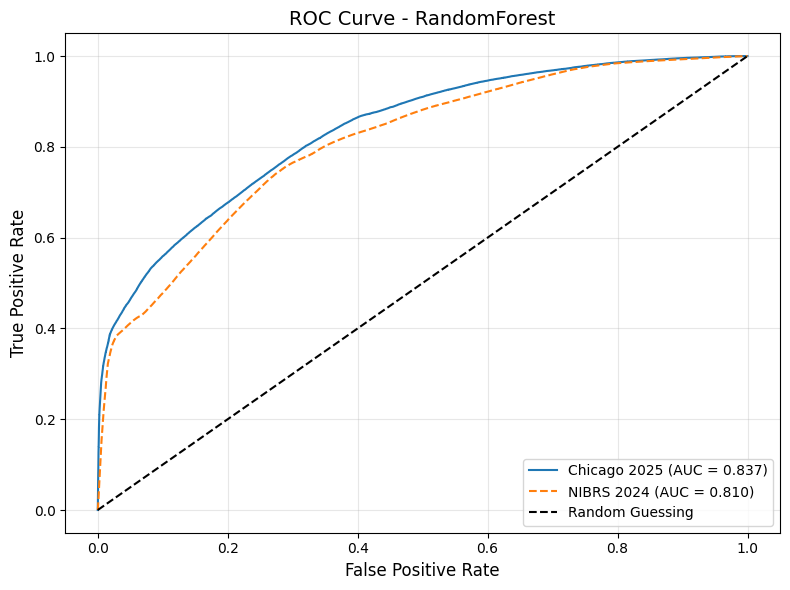


=== Top 5 Important Features: Random Forest ===
                                         Feature  Importance
24                         crime_against_Society    0.211996
23                        crime_against_Property    0.158730
28  offense_category_name_Drug/Narcotic Offenses    0.124999
12       location_name_Department/Discount Store    0.075628
19                  location_name_Residence/Home    0.059917


In [36]:
# ==========================================
# ROC Curve for Report
# ==========================================
roc_curve_plot('RandomForest', y_prob_rf_local, y_prob_rf_gen)

# ==========================================
# Feature Importance for Random Forest
# ==========================================
rf_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\n=== Top 5 Important Features: Random Forest ===")
print(rf_importance_df.head(5))

随机森林返回的前五大特征显示，模型在决策时高度依赖犯罪大类（Crime Hierarchy）和特定物理空间（Specific Location Context）。
  1. crime_against_Society (0.2120)：这是模型中最重要的特征。在犯罪学分类中，针对社会的犯罪（如毒品、非法武器携带）通常属于“警察主动干预型”。这类案件往往是“见人即捕”，因此它成为了区分是否逮捕的最强信号。
  2. crime_against_Property (0.1587)：财产类犯罪排名第二。由于此类案件（如盗窃、车内窃物）通常具有“事后报案”的特征，嫌疑人大多已离开现场，逮捕率天然较低。模型识别出这一特征，能够有效地排除那些低概率逮捕的样本。
  3. offense_category_name_Drug/Narcotic Offenses (0.1250)：这进一步验证了逻辑回归的发现。毒品犯罪是实战中逮捕率最高的类别之一。
  4. location_name_Department_Discount Store (0.0756)：商场/折扣店进入前五。这体现了环境辅助执法的作用：商场通常拥有完善的监控系统和驻场保安，保安先行扣留嫌疑人极大地提高了警方到场后实施逮捕的成功率。
  5. location_name_Residence_Home (0.0599)：住宅/家庭环境对模型也至关重要。这可能与家庭暴力案件（Domestic Battery）有关，此类案件往往有明确的报案人和现场嫌疑人，与街头随机犯罪相比，其逮捕逻辑完全不同。

## 5.梯度提升决策树：LightGBM (Gradient Boosting: LightGBM)
**【中文说明】**
在此模块中，我们使用了LightGBM模型。
  1. **特征预处理 (Feature Preprocessing)：** 针对 LightGBM 不支持 JSON 特殊字符的特性，我们首先对全量列名进行了正则清理。
  2. **高效训练 (High Efficiency)：** LightGBM 采用 Leaf-wise 的生长策略和基于直方图的算法，使其在处理百万级数据时，训练速度和内存效率远超传统的随机森林。
  3. **自动失衡处理 (Handling Imbalance)：** 通过参数 is_unbalance=True，模型会根据训练集中的真实比例自动缩放权重，这对于捕捉案发率极低但社会危害性大的逮捕事件（如绑架或谋杀）至关重要。
  4. **泛化性能 (Generalization)：** LightGBM 的梯度提升机制通过迭代纠错，能够提取出极其细微的预测信号，通常能在跨域泛化测试中取得最优表现。

**【English Explanation】**
In this module, we employ LightGBM model.
  1. **Feature Preprocessing:** Since LightGBM does not support special JSON characters in column names, we first applied regex cleaning to the entire feature set.
  2. **High Efficiency:** Utilizing a leaf-wise growth strategy and histogram-based algorithms, LightGBM outperforms traditional Random Forests in both training speed and memory efficiency when handling datasets of this magnitude.
  3. **Automated Imbalance Handling:** With is_unbalance=True, the model automatically scales weights based on the actual distribution in the training set. This is crucial for capturing high-impact arrest events with low base rates, such as kidnapping or homicide.
  4. **Generalization Performance:** Through iterative error correction (boosting), LightGBM extracts subtle predictive signals, typically achieving the best results in cross-domain generalization tests.

In [30]:
import re
X_train.columns = [re.sub(r'[\[\]<>,:"]', '_', col) for col in X_train.columns]
X_test_local.columns = [re.sub(r'[\[\]<>,:"]', '_', col) for col in X_test_local.columns]
X_test_gen.columns = [re.sub(r'[\[\]<>,:"]', '_', col) for col in X_test_gen.columns]

In [31]:
import lightgbm as lgb

print("Training LightGBM model...")

lgbm_model = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    boosting_type='gbdt',
    is_unbalance=True,
    random_state=42,
    n_jobs=-1
)
lgbm_model.fit(X_train, y_train)
print("LightGBM Training completed!\n")

Training LightGBM model...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 443069, number of negative: 2063657
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.120857 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 151
[LightGBM] [Info] Number of data points in the train set: 2506726, number of used features: 43
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.176752 -> initscore=-1.538509
[LightGBM] [Info] Start training from score -1.538509
LightGBM Training completed!



In [32]:
# ==========================================
# Run Tests and Output Results
# ==========================================
# Chicago 2025
y_pred_lgbm_local, y_prob_lgbm_local = evaluate_model(lgbm_model, X_test_local, y_test_local, test_name="Chicago 2025 (Local Temporal Test)")

# NIBRS 2024
y_pred_lgbm_gen, y_prob_lgbm_gen = evaluate_model(lgbm_model, X_test_gen, y_test_gen, test_name="NIBRS 2024 (Cross-Domain Generalization)")

=== Evaluation Results for: Chicago 2025 (Local Temporal Test) ===
Accuracy : 0.8261
Precision: 0.4648
Recall   : 0.5811
F1-Score : 0.5165
AUC-ROC  : 0.8111
---------------------------------------------
=== Evaluation Results for: NIBRS 2024 (Cross-Domain Generalization) ===
Accuracy : 0.7674
Precision: 0.6304
Recall   : 0.4498
F1-Score : 0.5250
AUC-ROC  : 0.7651
---------------------------------------------


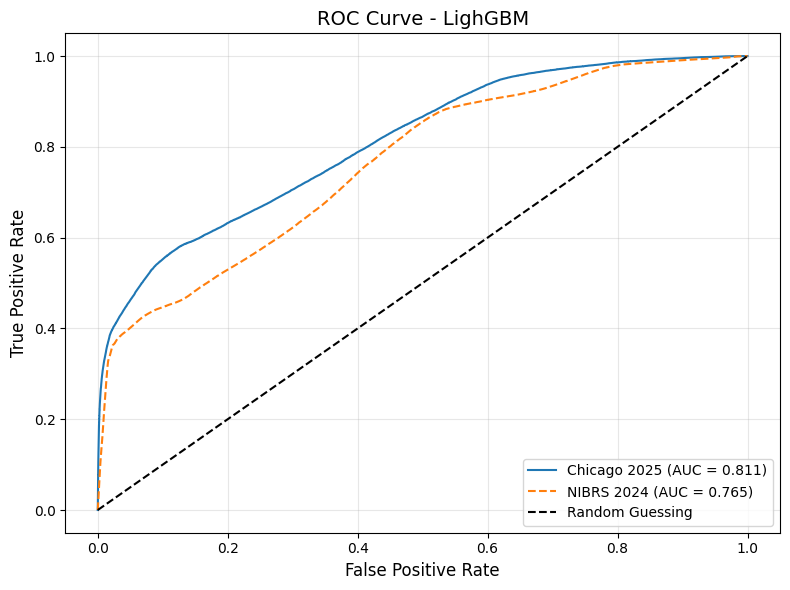


=== Top 5 Important Features: LightGBM(base on split) ===
       Feature  Importance
2     hour_sin        4262
3     hour_cos        3928
4    month_sin        2950
5    month_cos        2778
6  weekday_sin        2335

=== Top 5 Important Features: LightGBM(base on gain) ===
                                         Feature    Importance
24                         crime_against_Society  8.027926e+06
12       location_name_Department/Discount Store  1.927396e+06
22                          crime_against_Person  1.308463e+06
19                  location_name_Residence/Home  1.294207e+06
28  offense_category_name_Drug/Narcotic Offenses  1.257133e+06


In [42]:
# ==========================================
# ROC Curve for Report
# ==========================================
roc_curve_plot('LighGBM', y_prob_lgbm_local, y_prob_lgbm_gen)

# ==========================================
# Feature Importance for LightGBM(base on split)
# ==========================================
lgbm_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': lgbm_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\n=== Top 5 Important Features: LightGBM(base on split) ===")
print(lgbm_importance_df.head(5))

# ==========================================
# Feature Importance for LightGBM(base on gain)
# ==========================================
lgbm_importance_gain = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': lgbm_model.booster_.feature_importance(importance_type='gain')
}).sort_values(by='Importance', ascending=False)

print("\n=== Top 5 Important Features: LightGBM(base on gain) ===")
print(lgbm_importance_gain.head(5))

分裂次数 (Split-based Importance)：衡量特征在所有决策树中被用来切分数据的频率。这反映了模型对特征进行“精细化调节”的程度。重要特征均为周期性时间特征，虽然时间不能单独决定一个案件是否破获，但它是极其重要的修正因子。模型频繁地分割时间是为了在犯罪大类确定的基础上，根据当时的警力密度、光线条件等环境因素进行修正。例如，深夜在住宅区的盗窃案，其逮捕概率会根据具体小时数被模型反复修正。

总增益 (Gain-based Importance)：衡量特征在降低模型损失（Loss）方面的总贡献。这反映了特征的“决定性力量”。犯罪类型和犯罪地点对于降低模型Loss贡献较大，一旦获取这两类信息，模型的预测准确率会极大提升。